# MAST pulse runner

Generalizes `MAST_pulse.ipynb` into a function that takes a shot id (or a list of them) plus every parameter that a decision is made for and runs tmtx loops

In [1]:
# campaigns M5-M9, 2004-2013
import numpy as np
import requests
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

import os
import sys
import copy

BASE_URL = 'https://mastapp.site'

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path, 'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.pulse_design import TokaMaker_TORAX, BASE_CONFIG
import torax

def getOftEnv(nthreads=2):
    # OFT_env only allows one instance per kernel, reuse it if this kernel already made one
    return OFT_env.instance if hasattr(OFT_env, 'instance') else OFT_env(nthreads=nthreads)

In [2]:
def openShotGroup(shotId, group, level=1):
    """
    Opens a diagnostic group (efm, ayc, anb, summary, etc) for a shot,
    download of pulse only happen upon a read
    """
    path = f'json/shots/{shotId}' if level == 1 else f'json/level2/shots/{shotId}'
    try:
        response = requests.get(f'{BASE_URL}/{path}')
        response.raise_for_status()
        shot = response.json()
        shotUrl = shot['url'].replace('s3:/', shot['endpoint_url'])
        return xr.open_zarr(shotUrl, group=group)
    except requests.RequestException as e:
        print(f'failed to fetch shot {shotId}: {e}')
        return None

def openThomsonGroup(shotId, level=1):
    try:
        return openShotGroup(shotId, 'ayc', level=level)
    except KeyError:
        try:
            return openShotGroup(shotId, 'atm', level=level)
        except KeyError:
            raise KeyError(f'shot {shotId} has no Thomson group under ayc or atm')

## Geometry and profile helpers

In [ ]:
def buildGeqdsk(eq):
    # Builds a dict matching read_eqdsk()'s keys from an efm equilibrium slice.
    validCols = ~np.isnan(eq['psirz'].values).any(axis=0)
    gridR, gridZ = eq['gridr'].values, eq['gridz'].values
    lcfsR, lcfsZ = eq['lcfs_r'].values, eq['lcfs_z'].values
    lcfsValid = ~np.isnan(lcfsR) & ~np.isnan(lcfsZ)
    return {
        'nr': len(gridR),
        'nz': len(gridZ),
        'rdim': float(gridR.max() - gridR.min()),
        'zdim': float(gridZ.max() - gridZ.min()),
        'rleft': float(gridR.min()),
        'zmid': float((gridZ.max() + gridZ.min()) / 2.0),
        'rcentr': float(eq['rvtor']),
        'bcentr': float(eq['bvac_val']),
        'raxis': float(eq['magnetic_axis_r']),
        'zaxis': float(eq['magnetic_axis_z']),
        'psimag': float(eq['psi_axis']),
        'psibry': float(eq['psi_boundary']),
        'ip': float(eq['plasma_current_c']),
        'fpol': eq['fpsi_c'].values,
        'pres': eq['ppsi_c'].values,
        'ffprim': eq['ffprime'].values,
        'pprime': eq['pprime'].values,
        'psirz': eq['psirz'].values[:, validCols],
        'qpsi': eq['qpsi_c'].values,
        'rzout': np.column_stack([lcfsR[lcfsValid], lcfsZ[lcfsValid]]),
        'rzlim': np.column_stack([eq['limiterr'].values, eq['limiterz'].values]),
    }

def psiNormAtMidplane(rQuery, eq):
    # Maps real-space midplane R to normalized poloidal flux using the cleaned psirz grid
    validCols = ~np.isnan(eq['psirz'].values).any(axis=0)
    gridR, gridZ = eq['gridr'].values, eq['gridz'].values
    psirzClean = eq['psirz'].values[:, validCols]
    interp = RegularGridInterpolator((gridZ, gridR), psirzClean, bounds_error=False, fill_value=None)
    # Thomson chords at Z=0
    psi = interp(np.column_stack([np.zeros_like(rQuery), rQuery]))
    return (psi - float(eq['psi_axis'])) / (float(eq['psi_boundary']) - float(eq['psi_axis']))

def rhoTorNormFromPsiNorm(psiNormQuery, eq, lastSurface=1.0):
    # Converts normalized poloidal flux to normalized toroidal flux
    psiNorm65 = eq['psi_norm'].values
    q = eq['qpsi_c'].values
    torFlux = np.concatenate([[0.0], np.cumsum(0.5 * (q[1:] + q[:-1]) * np.diff(psiNorm65))])
    torFluxNorm = torFlux / np.interp(lastSurface, psiNorm65, torFlux)
    return np.interp(np.clip(psiNormQuery, 0, 1), psiNorm65, torFluxNorm) ** 0.5

def mapThomsonToRho(shotId, refTime, eq, lastSurface=1.0):
    # Throw out broken/NaN channels, relabel measurements by flux surface in format TORAX likes
    thomson = openThomsonGroup(shotId, level=1).sel(time=refTime, method='nearest')
    r, te, ne = thomson['radius'].values, thomson['te'].values, thomson['ne'].values
    valid = ~np.isnan(r) & ~np.isnan(te) & ~np.isnan(ne)
    rho = rhoTorNormFromPsiNorm(psiNormAtMidplane(r[valid], eq), eq, lastSurface)
    return rho, te[valid], ne[valid]

def mapCxrsToRho(shotId, refTime, eq, lastSurface=1.0):
    # CXRS isnt on every shot even when the beam is, not every era has the act group
    # Fall back to Ti = Te
    try:
        act = openShotGroup(shotId, 'act', level=1)
    except KeyError:
        return None
    if act is None or 'pla_temperature' not in act.data_vars:
        return None
    cxrs = act.sel(time=refTime, method='nearest')
    r, ti = cxrs['majorradius'].values, cxrs['pla_temperature'].values
    valid = ~np.isnan(r) & ~np.isnan(ti)
    if not np.any(valid):
        return None
    rho = rhoTorNormFromPsiNorm(psiNormAtMidplane(r[valid], eq), eq, lastSurface)
    return rho, ti[valid]

def buildNodeProfile(rho, values, rhoNodeCount=10, medianHalfWidth=0.1):
    # Running median onto a fixed rho grid, shared by every kinetic profile (Te, ne, Ti)
    # smooths noisy scattered measurements onto a clean grid
    sortOrder = np.argsort(rho)
    rhoSorted, valSorted = rho[sortOrder], values[sortOrder]
    rhoNodes = np.linspace(0.0, 1.0, rhoNodeCount)
    nodes = np.array([np.median(valSorted[np.abs(rhoSorted - x) <= medianHalfWidth]) if np.any(np.abs(rhoSorted - x) <= medianHalfWidth) else np.nan for x in rhoNodes])
    covered = ~np.isnan(nodes)
    return rhoNodes[covered], nodes[covered]

def gasPuffRate(shotId, coarseDt=0.01):
    # Need a particle rate for set_fueling. gas_injection only gives a cumulative
    # injected count, resample onto a coarser time grid before differentiating.
    # turns a running total into a rate
    ds = openShotGroup(shotId, 'gas_injection', level=2)
    try:
        t, total = ds['time'].values, ds['total_injected'].values
    except KeyError:
        raise KeyError(f'shot {shotId} gas_injection has no total_injected, only raw valve signals')
    tCoarse = np.arange(t.min(), t.max(), coarseDt) # resampled to 10 ms
    totalCoarse = np.interp(tCoarse, t, total)
    rateCoarse = np.clip(np.gradient(totalCoarse, tCoarse), 0, None)
    return dict(zip(tCoarse.tolist(), rateCoarse.tolist()))

In [4]:
channelToCoilSet = {
    'SOL': 'SOL', 'P2IL FEED': 'P2_INNER_LOWER', 'P2IU FEED': 'P2_INNER_UPPER',
    'P2OL FEED': 'P2_OUTER_LOWER', 'P2OU FEED': 'P2_OUTER_UPPER',
    'P3L FEED': 'P3_LOWER', 'P3U FEED': 'P3_UPPER',
    'P4L FEED': 'P4_LOWER', 'P4U FEED': 'P4_UPPER',
    'P5L FEED': 'P5_LOWER', 'P5U FEED': 'P5_UPPER',
    'P6L': 'P6_LOWER', 'P6U': 'P6_UPPER',
}

## Shot window

In [ ]:
def loadShotWindow(shotId):
    efmGroup = openShotGroup(shotId, 'efm', level=1)
    if efmGroup is None:
        raise KeyError(f'shot {shotId} efm fetch failed, see the network error printed above')
    try:
        efm = efmGroup.load()
    except KeyError:
        raise KeyError(f'shot {shotId} has no efm group at all')
    if 'plasma_current_c' not in efm.data_vars:
        efm['plasma_current_c'] = efm['plasma_current_x']
    validTimes = efm['time'].values[~np.isnan(efm['plasma_current_c'].values)]

    # EFIT reconstruction only between startup and ramp down, poloidal beta < 0 and li > 2 when plasma is small
    try:
        efmReliable = (efm['betap'].sel(time=validTimes).values > 0) & (efm['li'].sel(time=validTimes).values < 2.0)
    except KeyError:
        raise KeyError(f'shot {shotId} efm has no derived equilibrium (betap/li missing), EFIT reconstruction looks incomplete')

    # Longest stretch of reliable slices
    reliableTimes = validTimes[efmReliable]
    reliableRuns = np.split(reliableTimes, np.where(np.diff(reliableTimes) > 2.5 * np.median(np.diff(validTimes)))[0] + 1)
    pulseWindow = max(reliableRuns, key=lambda run: run[-1] - run[0])
    tPulseStart = float(pulseWindow[0])
    tPulseEnd = float(pulseWindow[-1])
    refTime = tPulseStart
    equilibrium = efm.sel(time=refTime, method='nearest')

    ayc = openThomsonGroup(shotId, level=1)[['te', 'ne', 'radius']].load()
    teValidTimeMask = ~np.isnan(ayc['te'].values).all(axis=1)
    thomsonValidTimes = ayc['time'].values[teValidTimeMask]
    thomsonRefTime = float(thomsonValidTimes[np.argmin(np.abs(thomsonValidTimes - refTime))])

    return efm, validTimes, tPulseStart, tPulseEnd, refTime, equilibrium, ayc, thomsonValidTimes, thomsonRefTime

def loadBeamPower(shotId, tPulseStart, tPulseEnd, powerThresholdMw=0.01):
    """
    NBI power trajectory. None for Ohmic shots or shots with no beam diagnostic. tot_sum_power 
    sums SS and SW so this check covers every supported heating type (SS Beam, SW Beam, 2 Beams). 
    Threshold sits above noise floor on confirmed Ohmic shots (sub 1 kW) and below real beam 
    power (100s of kW+).
    """
    try:
        anb = openShotGroup(shotId, 'anb', level=1)
    except KeyError:
        return None
    if anb is None or 'tot_sum_power' not in anb.data_vars:
        return None
    power = anb['tot_sum_power'].sel(time=slice(tPulseStart, tPulseEnd))
    if np.nanmax(power.values) < powerThresholdMw:
        return None
    return {float(t): float(p) * 1e6 for t, p in zip(power['time'].values, power.values) if not np.isnan(p)}

## Seed equilibria

In [ ]:
def buildSeedEquilibria(mygs, shotId, efm, seedTimes, channelToCoilSet, coilBoundAmps, fluxWeightCandidates=(10.0, 1.0, 0.1)):
    mygs.set_coil_bounds({name: [-coilBoundAmps, coilBoundAmps] for name in mygs.coil_sets})  # Loose bounds, not real coil limits

    # Generate and save one seed eqdsk per seed time
    seedFiles = []
    os.makedirs('seeds', exist_ok=True)

    # Same PF current record for every seed time, get once
    pfActiveCurrents = openShotGroup(shotId, 'pf_active', level=2)

    for i, seedTime in enumerate(seedTimes):
        seedEq = efm.sel(time=seedTime, method='nearest')
        seedGeqdsk = buildGeqdsk(seedEq)

        regTerms = []
        for channelName, coilSetName in channelToCoilSet.items():
            realCurrentAmps = float(pfActiveCurrents['coil_current'].sel(current_channel=channelName).sel(time=seedTime, method='nearest'))
            netTurns = mygs.coil_sets[coilSetName]['net_turns']
            regTerms.append(mygs.coil_reg_term({coilSetName: 1.0}, target=realCurrentAmps * netTurns, weight=1.0e-2))
        mygs.set_coil_reg(reg_terms=regTerms)

        mygs.set_targets(Ip=abs(seedGeqdsk['ip']), pax=abs(seedGeqdsk['pres'][0]))

        rzout = seedGeqdsk['rzout']
        r0 = float(seedEq['magnetic_axis_r'])
        z0 = float(seedEq['magnetic_axis_z'])
        a = float((rzout[:, 0].max() - rzout[:, 0].min()) / 2.0)
        kappa = float((rzout[:, 1].max() - rzout[:, 1].min()) / (2.0 * a))

        # A plasma this early has almost no flux depth between axis and boundary
        for attempt, weight in enumerate(fluxWeightCandidates):
            # Set boundary flux to EFIT value so seed has physical absolute flux
            mygs.set_flux(rzout, np.full(len(rzout), float(seedEq['psi_boundary'])), weights=np.full(len(rzout), weight))
            mygs.init_psi(r0=r0, z0=z0, a=a, kappa=kappa, delta=0.0)
            try:
                mygs.solve()
                break
            except Exception as e:
                if attempt == len(fluxWeightCandidates) - 1:
                    raise
                print(f'seed {i} failed at flux weight={weight}, retrying at {fluxWeightCandidates[attempt + 1]}: {e}')

        seedPath = f'seeds/seed_{i}.eqdsk'
        mygs.save_eqdsk(seedPath, cocos=2)  # save_eqdsk defaults to cocos=7, TokaMaker_TORAX assumes cocos=2 internally
        seedFiles.append(seedPath)

    return seedFiles

def pickLastSurfaceFactor(seedFiles, candidates=(0.95, 0.9, 0.85)):
    # TORAX cant build flux surface geometry to separatrix of diverted plasmas, use largest last surface factor it accepts
    for factor in candidates:
        try:
            for seedFile in seedFiles:
                geometryCheck = copy.deepcopy(BASE_CONFIG)
                geometryCheck['geometry'] = {'geometry_type': 'eqdsk', 'geometry_directory': os.getcwd(), 'last_surface_factor': factor, 'Ip_from_parameters': False, 'geometry_file': seedFile, 'cocos': 2}
                torax.ToraxConfig.from_dict(geometryCheck)
            return factor
        except Exception:
            continue
    raise ValueError('TORAX rejects the seed equilibria at every last surface factor tried')

## Initial profiles and edge conditions

In [ ]:
def buildInitialProfiles(shotId, thomsonRefTime, equilibrium, lastSurface, efm, validTimes, tPulseStart, tPulseEnd,
                          edgeTe, edgeDensityFraction, gasPuffCoarseDt=0.01, rhoNodeCount=10, medianHalfWidth=0.1):
    # Initial kinetic profiles, Te/ne from the first Thomson slice in the window
    rhoInit, teInit, neInit = mapThomsonToRho(shotId, thomsonRefTime, equilibrium, lastSurface)

    gasPuffSTotal = gasPuffRate(shotId, coarseDt=gasPuffCoarseDt)

    # Edge conditions from constants, density is fixed fraction of Greenwald density from Ip and EFIT minor radius
    tEfm = validTimes[(validTimes >= tPulseStart) & (validTimes <= tPulseEnd)]
    aMinor = np.array([(np.nanmax(efm.sel(time=t)['lcfs_r'].values) - np.nanmin(efm.sel(time=t)['lcfs_r'].values)) / 2.0 for t in tEfm])
    ipEfm = np.abs(efm['plasma_current_c'].sel(time=tEfm).values)
    greenwaldDensity = ipEfm / 1e6 / (np.pi * aMinor ** 2) * 1e20
    edgeTeBc = {float(t): edgeTe for t in tEfm}
    edgeNeBc = {float(t): float(edgeDensityFraction * n) for t, n in zip(tEfm, greenwaldDensity)}

    # Drop channels outside the last surface where rho > 1, convert Te to keV
    insidePlasma = rhoInit < 1.0
    rhoNodes, teNodes = buildNodeProfile(rhoInit[insidePlasma], teInit[insidePlasma] / 1000.0, rhoNodeCount, medianHalfWidth)
    _, neNodes = buildNodeProfile(rhoInit[insidePlasma], neInit[insidePlasma], rhoNodeCount, medianHalfWidth)
    neProfile = {0.0: {float(r): float(n) for r, n in zip(rhoNodes, neNodes)}}
    teProfile = {0.0: {float(r): float(t) for r, t in zip(rhoNodes, teNodes)}}

    # CXRS Ti where the shot and era have it, Te stands in otherwise same as the edge value below
    cxrs = mapCxrsToRho(shotId, thomsonRefTime, equilibrium, lastSurface)
    if cxrs is not None:
        rhoTi, tiInit = cxrs
        insideTi = rhoTi < 1.0
        rhoTiNodes, tiNodes = buildNodeProfile(rhoTi[insideTi], tiInit[insideTi] / 1000.0, rhoNodeCount, medianHalfWidth)
        tiProfile = {0.0: {float(r): float(t) for r, t in zip(rhoTiNodes, tiNodes)}}
    else:
        tiProfile = teProfile

    return neProfile, teProfile, tiProfile, edgeNeBc, edgeTeBc, gasPuffSTotal

## Compare to experiment

In [8]:
def compareToExperiment(tmtx, efm, ayc, validTimes, thomsonValidTimes, tPulseStart, tPulseEnd, lastSurface, plot=True, verbose=True):
    # Experimental timestamps inside simulated window
    timeSources = {
        'EFIT (efm)': validTimes,
        'core Thomson (ayc)': thomsonValidTimes,
    }
    if verbose:
        for label, times in timeSources.items():
            inWindow = times[(times >= tPulseStart) & (times <= tPulseEnd)]
            print(f'{label:20s} {len(inWindow):5d} timestamps, median step {1e3 * np.median(np.diff(inWindow)):.2f} ms')
        txTimes = tmtx._data_tree.profiles.T_e.coords['time'].values
        print(f'{"TORAX output":20s} {len(txTimes):5d} timestamps')
        print(f'{"TokaMaker solves":20s} {len(tmtx.results["psi_lcfs_tm"]["x"]):5d} timestamps')

    # Core Thomson Te/ne at every measurement time from channel nearest to magnetic axis inside the LCFS
    txTe = tmtx._data_tree.profiles.T_e
    txNe = tmtx._data_tree.profiles.n_e

    compareTimes = thomsonValidTimes[(thomsonValidTimes >= tPulseStart) & (thomsonValidTimes <= tPulseEnd)]
    usedTimes, coreRho, teMeasured, teSimulated, neMeasured, neSimulated = [], [], [], [], [], []
    for t in compareTimes:
        eq = efm.sel(time=t, method='nearest')
        thomsonNow = ayc.sel(time=t)
        r, te, ne = thomsonNow['radius'].values, thomsonNow['te'].values, thomsonNow['ne'].values
        valid = ~np.isnan(r) & ~np.isnan(te) & ~np.isnan(ne)
        rho = rhoTorNormFromPsiNorm(psiNormAtMidplane(r[valid], eq), eq, lastSurface)
        try:
            inside = np.where(rho < 1.0)[0]
            core = inside[np.argmin(rho[inside])]
        except ValueError:
            continue
        usedTimes.append(float(t))
        coreRho.append(rho[core])
        teMeasured.append(te[valid][core] / 1000.0)
        neMeasured.append(ne[valid][core])
        # TORAX output at same time and rho interpolated from output grid
        teSimulated.append(float(txTe.interp(time=t, rho_norm=rho[core])))
        neSimulated.append(float(txNe.interp(time=t, rho_norm=rho[core])))

    usedTimes, coreRho = np.array(usedTimes), np.array(coreRho)
    teMeasured, teSimulated = np.array(teMeasured), np.array(teSimulated)
    neMeasured, neSimulated = np.array(neMeasured), np.array(neSimulated)

    if verbose:
        print('time [s]   rho    measured Te [keV]   simulated Te [keV]')
        for k in range(0, len(usedTimes), max(1, len(usedTimes) // 10)):
            print(f'{usedTimes[k]:7.3f}  {coreRho[k]:5.2f}  {teMeasured[k]:12.3f}  {teSimulated[k]:15.3f}')

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(usedTimes, teMeasured, 'k.', label='Thomson (measured)')
        ax.plot(usedTimes, teSimulated, 'r-', label='TORAX (simulated)')
        ax.set_ylabel('core Te [keV]')
        ax.legend()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(usedTimes, neMeasured, 'k.', label='Thomson (measured)')
        ax.plot(usedTimes, neSimulated, 'r-', label='TORAX (simulated)')
        ax.set_ylabel('core ne [1e19 m^-3]')
        ax.legend()

    teRms = float(np.sqrt(np.mean((teMeasured - teSimulated) ** 2))) if len(teMeasured) else float('nan')
    neRms = float(np.sqrt(np.mean((neMeasured - neSimulated) ** 2))) if len(neMeasured) else float('nan')

    return {
        'times': usedTimes, 'coreRho': coreRho,
        'teMeasured': teMeasured, 'teSimulated': teSimulated, 'teRms': teRms,
        'neMeasured': neMeasured, 'neSimulated': neSimulated, 'neRms': neRms,
    }

## Run one pulse

In [ ]:
def runMastPulse(shotId, meshPath='MAST_info/MAST_mesh.h5', outputDir='pulse_outputs', runName=None,
                  gasFuelingEfficiency=0.02, edgeTe=0.049, edgeDensityFraction=0.12, Zeff=1.7,
                  nSeeds=5, order=2, maxits=100, coilBoundAmps=1.0e7, txDt=0.005, tmNPoints=20,
                  lastSurfaceFactorCandidates=(0.95, 0.9, 0.85), fluxWeightCandidates=(10.0, 1.0, 0.1),
                  bootstrapModel='sauter', transportModel='angioni_sauter',
                  sawtoothSCritical=1.0, maxLoop=2, outputMode='minimal', gasPuffCoarseDt=0.01,
                  rhoNodeCount=10, medianHalfWidth=0.1, beamPowerThresholdMw=0.01, beamAbsorptionFraction=1.0,
                  beamHeatLoc=0.0, beamHeatWidth=0.25, oftEnv=None, plot=True, verbose=True):
    """
    Runs one MAST shot with tmtx. Category 1 inputs (Ip, LCFS, profiles, gas puff, coil currents, 
    NBI power, CXRS Ti) come straight from the shot. Heating branch (Ohmic vs SS/SW/2 Beams) auto picked 
    from anb, doesnt depend on data_cleaning.ipynb having been run first. oftEnv lets
    runMastPulses share one OFT_env across a batch, since only one can exist per kernel.
    """
    inputConstants = {
        'gasFuelingEfficiency': gasFuelingEfficiency,
        'edgeTe': edgeTe,
        'edgeDensityFraction': edgeDensityFraction,
        'Zeff': Zeff,
    }
    runName = runName or f'mast_pulse_{shotId}'

    originalCwd = os.getcwd()
    meshPathAbs = os.path.abspath(meshPath)

    myOFT = oftEnv if oftEnv is not None else getOftEnv()
    mygs = TokaMaker(myOFT)
    mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh(meshPathAbs)
    mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
    mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)

    efm, validTimes, tPulseStart, tPulseEnd, refTime, equilibrium, ayc, thomsonValidTimes, thomsonRefTime = loadShotWindow(shotId)
    beamPower = loadBeamPower(shotId, tPulseStart, tPulseEnd, beamPowerThresholdMw)

    F0 = float(equilibrium['rvtor'] * equilibrium['bvac_val'])
    mygs.setup(order=order, F0=F0)
    # Max solver iterations per equilibrium
    mygs.settings.maxits = maxits

    # seeds/outputs
    runDir = os.path.join(originalCwd, outputDir, f'shot_{shotId}')
    os.makedirs(os.path.join(runDir, 'seeds'), exist_ok=True)
    os.chdir(runDir)
    try:
        # Seed equilibria, evenly spaced through window
        seedTimes = [float(t) for t in np.linspace(tPulseStart, tPulseEnd, nSeeds)]
        seedFiles = buildSeedEquilibria(mygs, shotId, efm, seedTimes, channelToCoilSet, coilBoundAmps, fluxWeightCandidates)

        lastSurface = pickLastSurfaceFactor(seedFiles, lastSurfaceFactorCandidates)

        def attemptFly(lastSurface):
            neProfile, teProfile, tiProfile, edgeNeBc, edgeTeBc, gasPuffSTotal = buildInitialProfiles(
                shotId, thomsonRefTime, equilibrium, lastSurface, efm, validTimes, tPulseStart, tPulseEnd,
                inputConstants['edgeTe'], inputConstants['edgeDensityFraction'], gasPuffCoarseDt, rhoNodeCount, medianHalfWidth)

            # Build the coupled object
            tmtx = TokaMaker_TORAX(
                t_init=tPulseStart,
                t_final=tPulseEnd,
                eqtimes=seedTimes,
                g_eqdsk_arr=seedFiles,
                tokamaker_obj=mygs,
                tx_dt=txDt,  # MAST pulses run ~0.5s
                tm_times=list(np.linspace(tPulseStart, tPulseEnd, tmNPoints)),
                last_surface_factor=lastSurface,
            )

            # Use the Sauter bootstrap model and low sensitivity sawtooth trigger
            tmtx.load_TORAX_config({
                'neoclassical': {'bootstrap_current': {'model_name': bootstrapModel}, 'transport': {'model_name': transportModel}},
                'mhd': {'sawtooth': {'trigger_model': {'model_name': 'simple', 's_critical': sawtoothSCritical}}},
            })

            # Generic heat stands in for NBI, only set when anb shows real beam power in window
            if beamPower is not None:
                tmtx.set_heating(generic_heat={t: p * beamAbsorptionFraction for t, p in beamPower.items()}, generic_heat_loc=beamHeatLoc, generic_heat_width=beamHeatWidth)

            # Ip and gas puff
            ipTrajectory = {float(t): abs(float(i)) for t, i in zip(efm['time'].values[~np.isnan(efm['plasma_current_c'].values)], efm['plasma_current_c'].values[~np.isnan(efm['plasma_current_c'].values)])}
            tmtx.set_Ip(ipTrajectory)

            # Gas puff scaled by fueling efficiency, 2% of injected molecules become confined electrons inside rho = 1
            tmtx.set_fueling(gas_puff_S_total={t: inputConstants['gasFuelingEfficiency'] * rate for t, rate in gasPuffSTotal.items()}, gas_puff_decay_length=0.05)

            tmtx.set_ne(neProfile, right_bc=edgeNeBc)
            tmtx.set_Te(teProfile, right_bc=edgeTeBc)

            # CXRS Ti when buildInitialProfiles found it, Te substituted in already otherwise
            tmtx.set_Ti(tiProfile, right_bc=edgeTeBc)

            # carbon impurity from PFCs, Deuterium only
            tmtx.set_plasma_composition(main_ion={'D': 1.0}, Zeff=inputConstants['Zeff'], impurity='C')  # MAST is deuterium only, no tritium

            tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)
            tmtx.set_TokaMaker_coil_reg()  # defaults to +-45 MA-turns per coil

            tmtx.fly(run_name=runName, output_mode=outputMode, max_loop=maxLoop)
            return tmtx, teProfile, tiProfile

        # Heating moves boundary past seed-only check validation, fly() can fail tracing 
        # flux surfaces near the LCFS deep in the loop. 
        remainingFactors = [f for f in lastSurfaceFactorCandidates if f <= lastSurface]
        for attempt, factor in enumerate(remainingFactors):
            try:
                tmtx, teProfile, tiProfile = attemptFly(factor)
                lastSurface = factor
                break
            except Exception as e:
                if attempt == len(remainingFactors) - 1:
                    raise
                print(f'fly() failed at last_surface_factor={factor}, retrying at {remainingFactors[attempt + 1]}: {e}')

        if verbose:
            tmtx.summary()
        if plot:
            tmtx.plot_scalars()
            tmtx.plot_profile_evolution()
            tmtx.plot_lcfs_evolution()
            tmtx.plot_coils()

        # maxLoop=0 never runs the coupling loop, so TORAX output isnt populated to compare against
        if maxLoop > 0:
            diagnostics = compareToExperiment(tmtx, efm, ayc, validTimes, thomsonValidTimes, tPulseStart, tPulseEnd, lastSurface, plot=plot, verbose=verbose)
        else:
            if verbose:
                print('maxLoop=0, no coupled TORAX output to compare, skipping Te/ne comparison')
            diagnostics = {'teRms': None, 'neRms': None}
        diagnostics['tPulseStart'] = tPulseStart
        diagnostics['tPulseEnd'] = tPulseEnd
        diagnostics['lastSurface'] = lastSurface
        diagnostics['beamHeating'] = beamPower is not None
        diagnostics['cxrsTiUsed'] = tiProfile is not teProfile

        return tmtx, diagnostics
    finally:
        os.chdir(originalCwd)

## Run a batch of pulses

In [10]:
def runMastPulses(shotIds, **kwargs):
    # OFT_env only allows one instance per kernel, reuse one if this kernel already made one
    myOFT = getOftEnv()
    results = {}
    for shotId in shotIds:
        print(f'--- shot {shotId} ---')
        try:
            results[shotId] = runMastPulse(shotId, oftEnv=myOFT, **kwargs)
        except Exception as e:
            print(f'shot {shotId} failed: {e}')
            results[shotId] = None
    return results

## Example

--- shot 14625 ---

**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.376E+01
    # of points  =   15166
    # of edges   =   45356
    # of cells   =   30191
    # of boundary points =     139
    # of boundary edges  =     139
    # of boundary cells  =     139
  Resolution statistics:
    hmin =  1.000E-04
    hrms =  3.486E-02
    hmax =  1.673E-01
  Surface grounded at vertex    3336


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    5.8700000000000002E-003


/var/folders/0c/497qwkps0n92lm8mgp_t18800000gn/T/ipykernel_13645/2547876786.py:35: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(rzout, np.full(len(rzout), float(seedEq['psi_boundary'])), weights=np.full(len(rzout), weight))


Starting non-linear GS solver
     1  8.8653E-01  3.5643E-02  4.6099E-03  6.1798E-01  2.1892E-03 -0.0000E+00
     2  9.6430E-01  2.4966E-02  4.1608E-03  6.1054E-01  2.3696E-03 -0.0000E+00
     3  9.9225E-01  2.2856E-02  2.3371E-03  6.0726E-01  2.5159E-03 -0.0000E+00
     4  1.0038E+00  2.2250E-02  1.1920E-03  6.0569E-01  2.5380E-03 -0.0000E+00
     5  1.0087E+00  2.2042E-02  5.9034E-04  6.0496E-01  2.5525E-03 -0.0000E+00
     6  1.0110E+00  2.1963E-02  2.8860E-04  6.0462E-01  2.5615E-03 -0.0000E+00
     7  1.0120E+00  2.1930E-02  1.4018E-04  6.0446E-01  2.5669E-03 -0.0000E+00
     8  1.0124E+00  2.1915E-02  6.7781E-05  6.0439E-01  2.5702E-03 -0.0000E+00
     9  1.0126E+00  2.1909E-02  3.2667E-05  6.0435E-01  2.5722E-03 -0.0000E+00
    10  1.0127E+00  2.1906E-02  1.5706E-05  6.0433E-01  2.5734E-03 -0.0000E+00
    11  1.0128E+00  2.1904E-02  7.5390E-06  6.0433E-01  2.5741E-03 -0.0000E+00
    12  1.0128E+00  2.1904E-02  3.6150E-06  6.0432E-01  2.5745E-03 -0.0000E+00
    13  1.0128E+00  2.

Simulating (t=0.11500):  99%|█████████▉| 99/100 [00:00<00:00, 879.29it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=0.41500): 100%|██████████| 100/100 [00:15<00:00,  6.63it/s]


  TORAX: done (cflux=0.4474 Wb)
  TokaMaker: solving 20 equilibria...


  TM loop 1:  10%|█         | 2/20 [00:06<00:52,  2.91s/solve], t=0.04s FAIL  

  TM loop 1: 100%|██████████| 20/20 [02:23<00:00,  7.18s/solve], t=0.41s OK(L0)


  TokaMaker: 19/20 solved (cflux=0.4931 Wb)
	TM summary: 19/20 solved. Levels: analytic: 2, ped_smoothing: 1, raw tx profs: 13, sign_flip: 3. Failures: 1.
  Loop 1 result: conv_err=0.000% | TX-TM diff=9.2634% | cflux_TX=0.4474 Wb | cflux_TM=0.4931 Wb

  Max loop index (1) reached (err=0.000%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      0.4474           0.4931           9.2634        
  Total sim time: 2m 42.2s
  Outputs saved to: ./TokaMaker_TORAX_outputs/mast_pulse_14625_2026-10-05_213012
  Log file: /Users/d22fish/Documents/7FusionResearch/Software/Research/pulse_outputs/shot_14625/TokaMaker_TORAX_log_mast_pulse_14625_2026-10-05_213012.log

  TokaMaker_TORAX Physics Summary
  Q_max                           0
  Q_max_time                      0.015
  Q_flattop_avg                   0
  E_fusion_total_MJ               0
  beta_N_max                      1.758
  H98_max                         2.835
  H98_fl

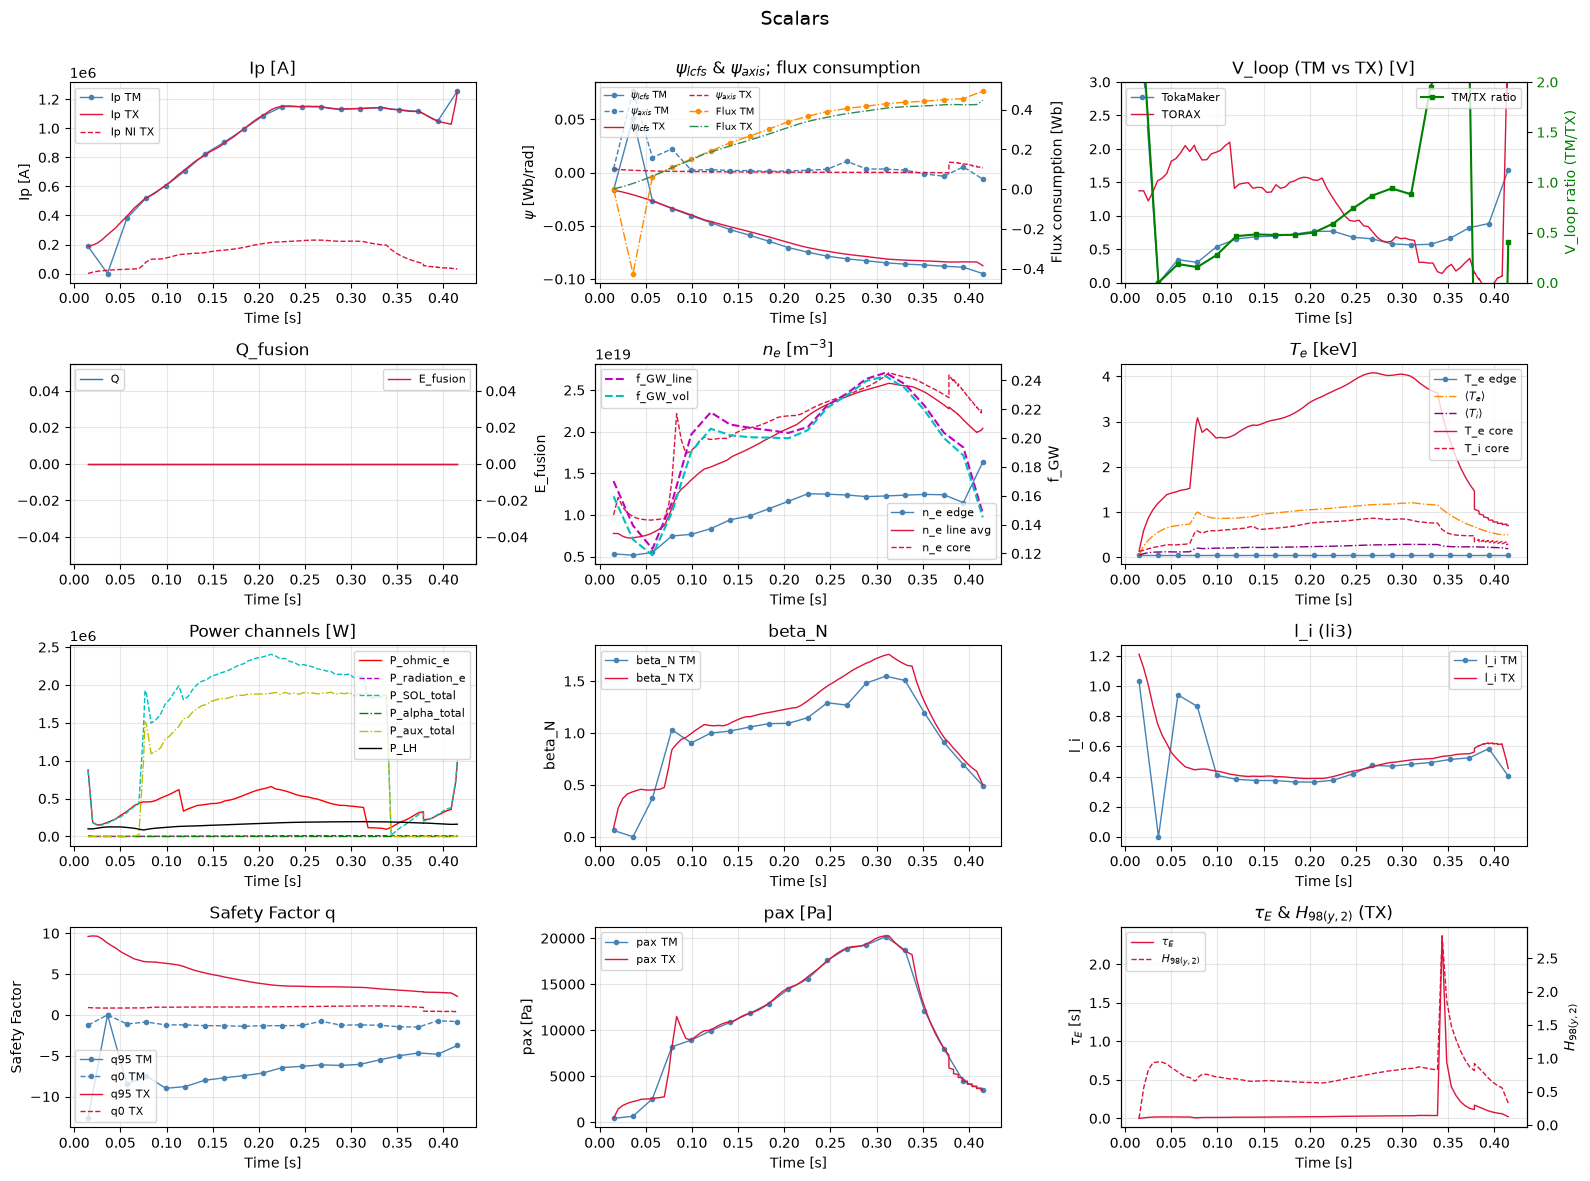

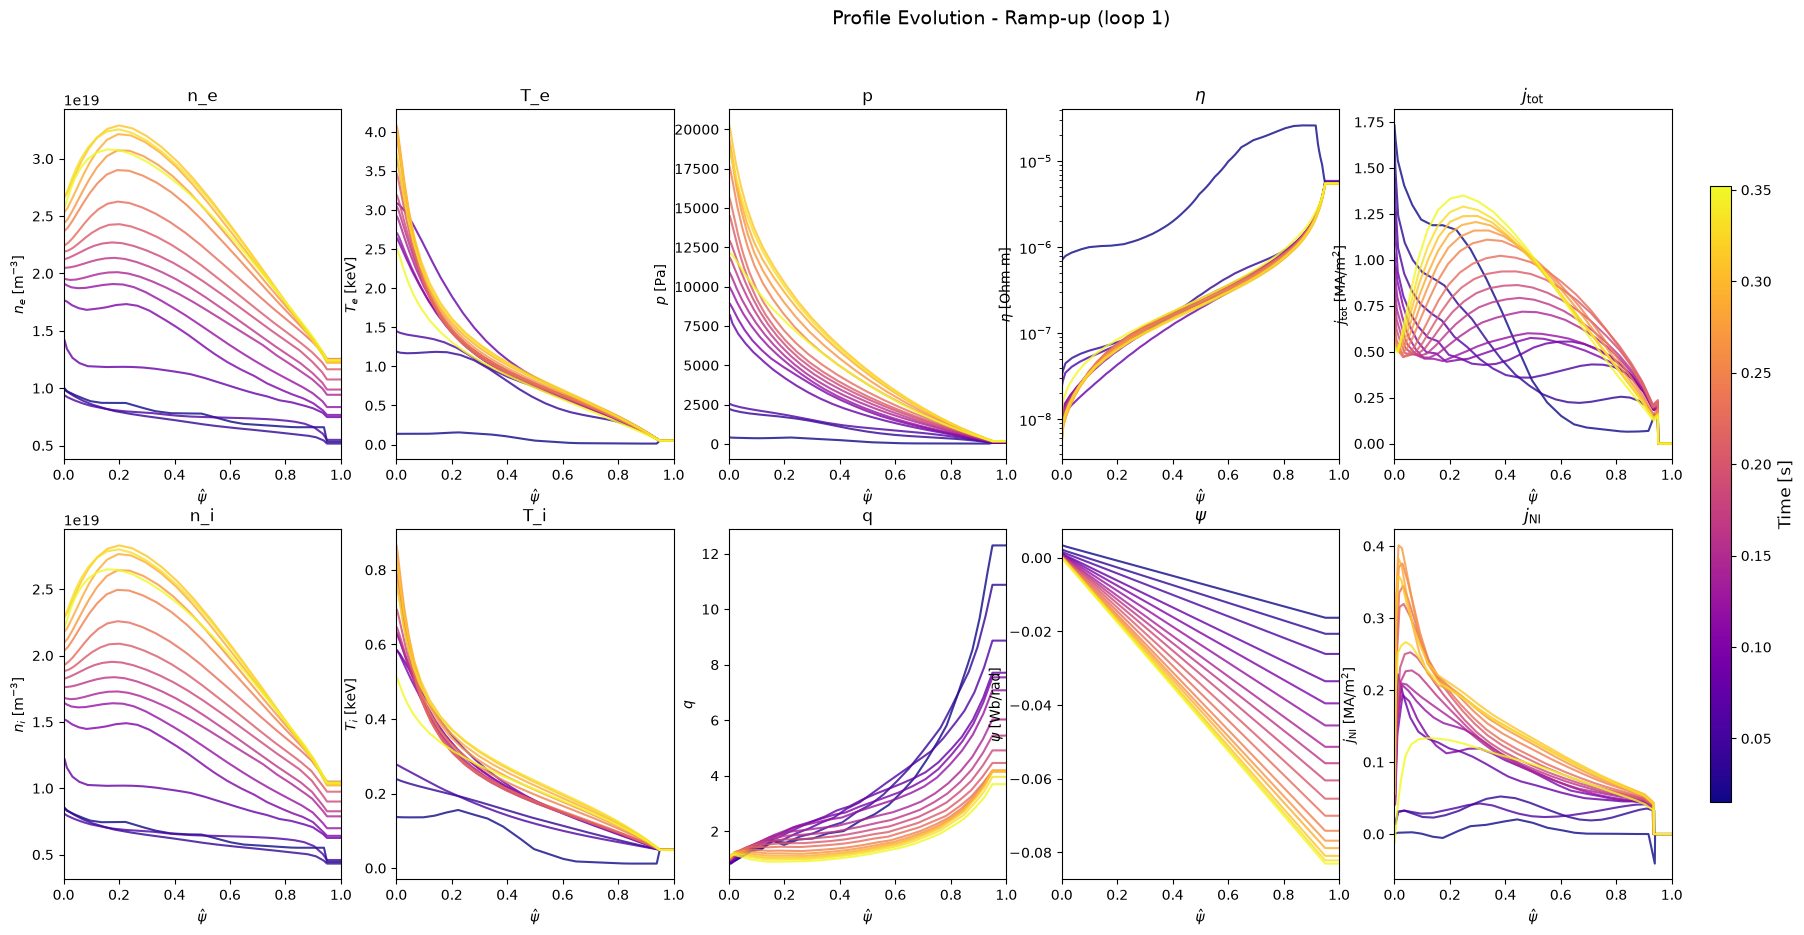

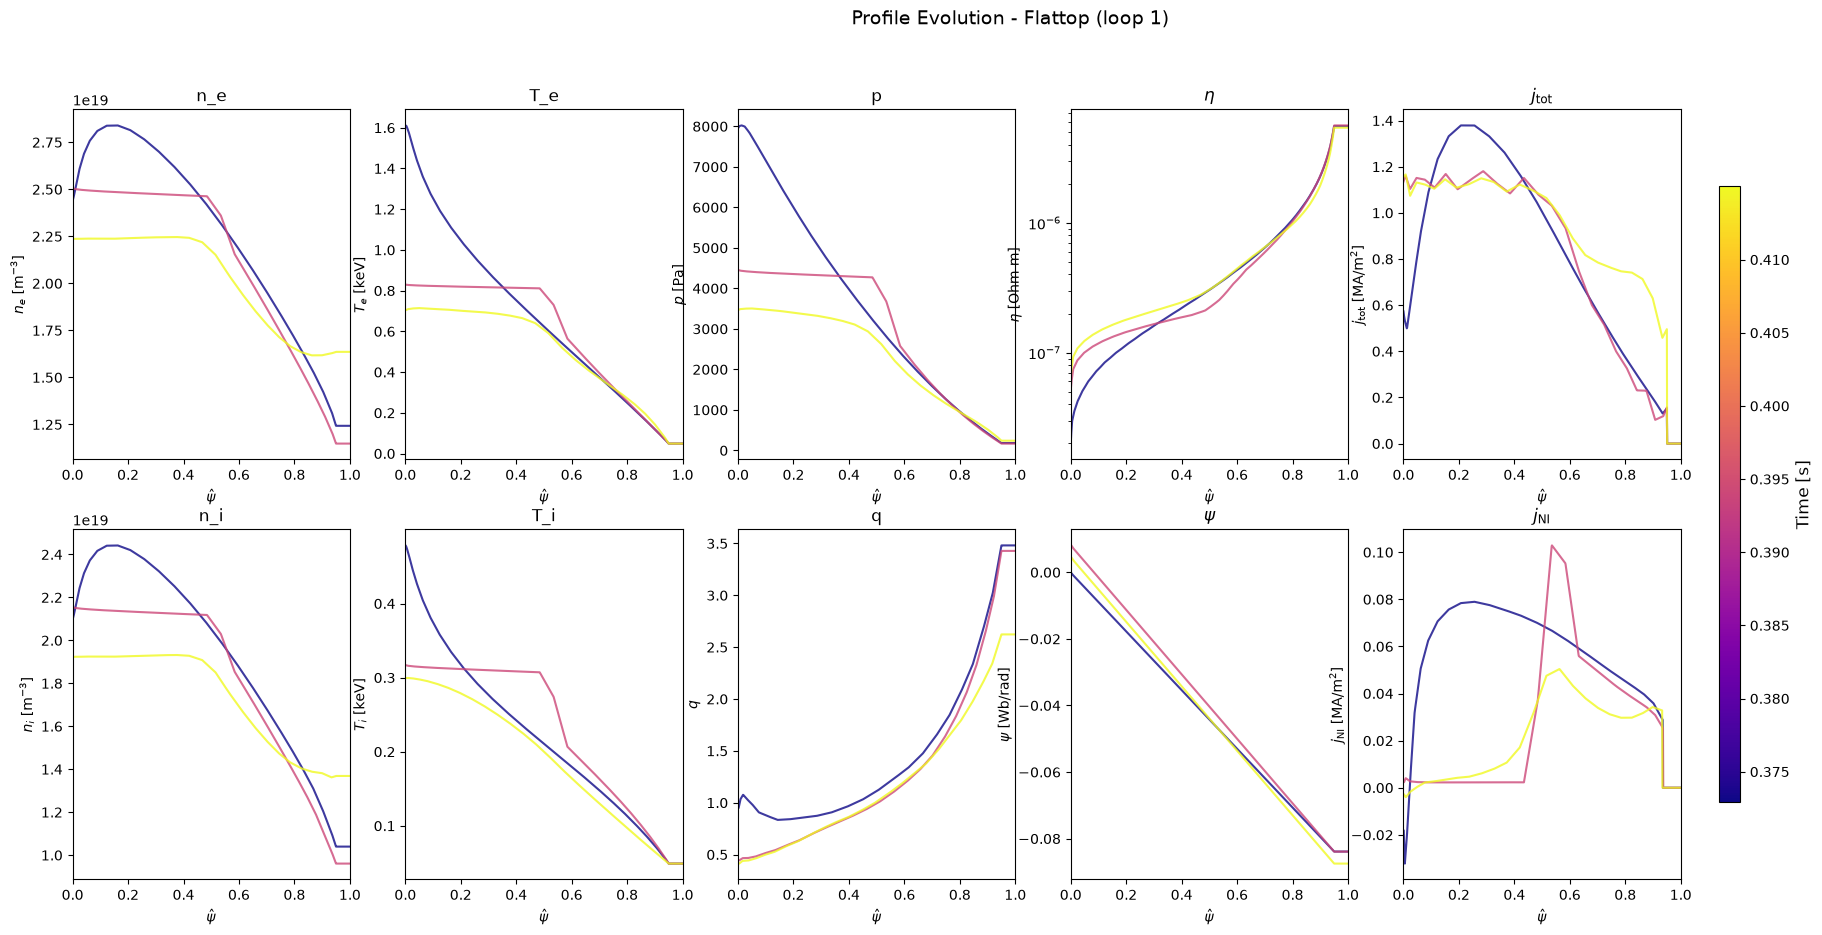

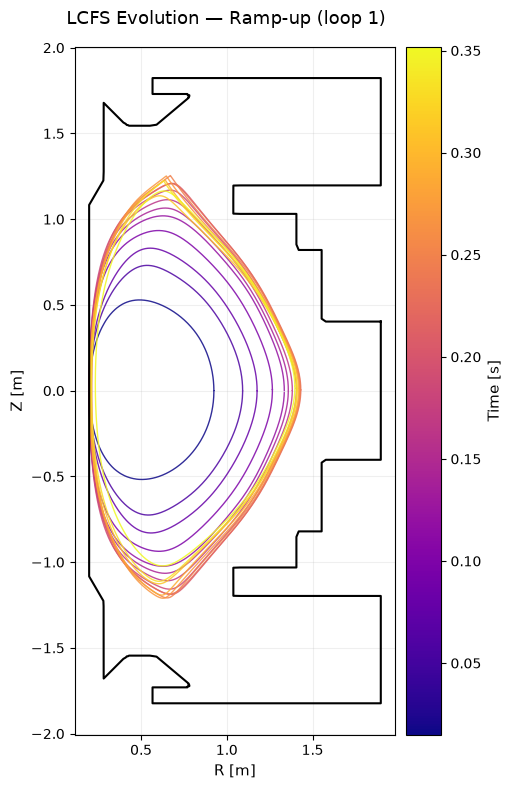

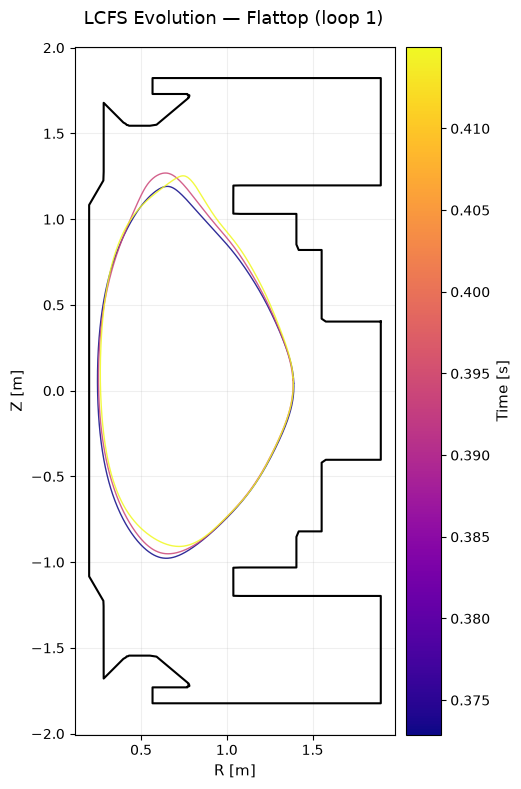

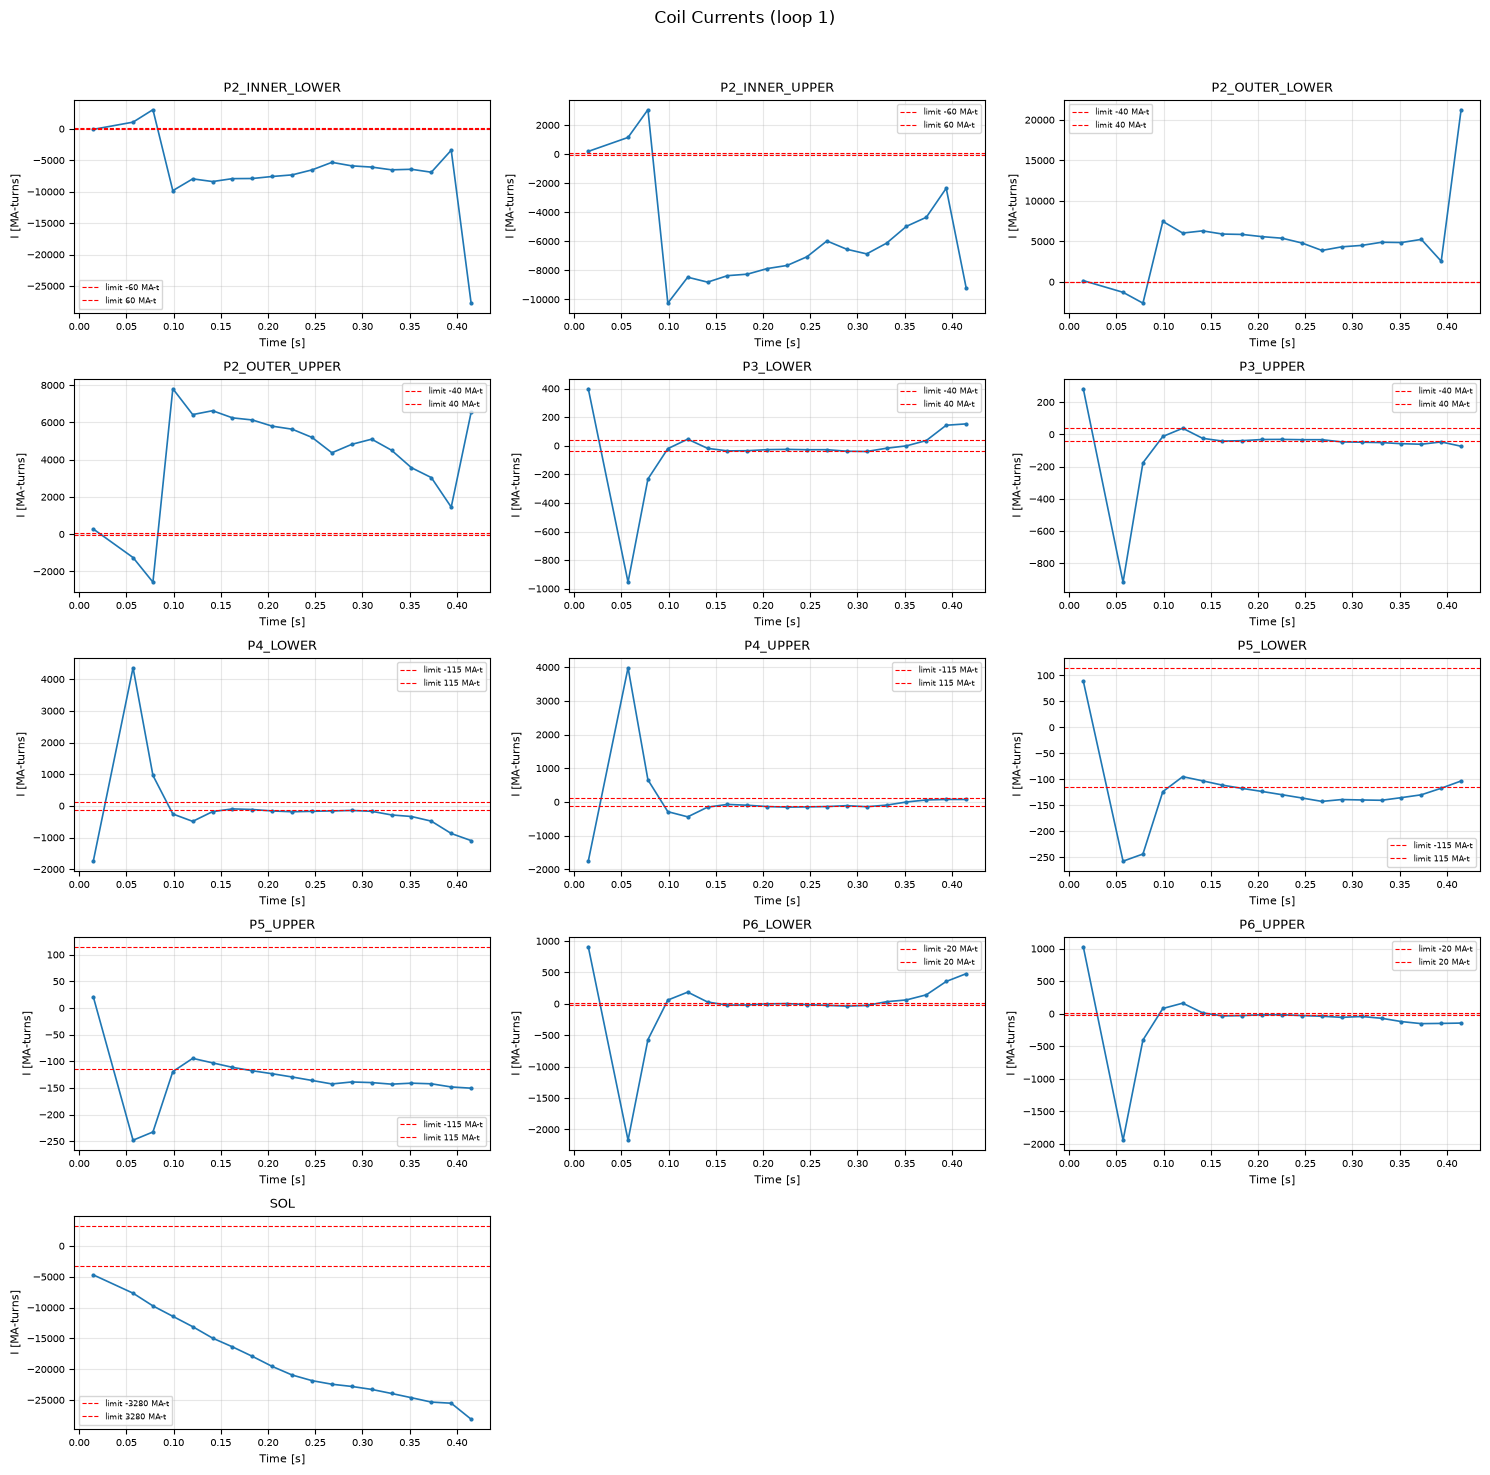

EFIT (efm)              81 timestamps, median step 5.00 ms
core Thomson (ayc)      40 timestamps, median step 15.00 ms
TORAX output            91 timestamps
TokaMaker solves        20 timestamps
time [s]   rho    measured Te [keV]   simulated Te [keV]
  0.019   0.05         0.176            0.520
  0.059   0.03         0.282            1.474
  0.099   0.01         0.712            2.642
  0.139   0.04         0.983            2.904
  0.179   0.03         1.081            3.134
  0.219   0.04         1.056            3.592
  0.259   0.04         1.514            4.001
  0.299   0.05         1.730            4.002
  0.339   0.05         1.616            3.526
  0.379   0.03         1.283            1.058
--- shot 14626 ---

**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.376E+01
    # of points  =   15166
    # of edges   =   45356
    # of cells   =   30191
    # of boundary points =     1

/var/folders/0c/497qwkps0n92lm8mgp_t18800000gn/T/ipykernel_13645/2547876786.py:35: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(rzout, np.full(len(rzout), float(seedEq['psi_boundary'])), weights=np.full(len(rzout), weight))


Starting non-linear GS solver
 DGETRF           1
seed 0 failed at flux weight=10.0, retrying at 1.0: Error in solve: Matrix solve failed for targets         
 Timing:   1.0875000152736902E-002
   Source:     5.1899999380111694E-003
   Solve:      4.0400000289082527E-003
   Boundary:   3.3199973404407501E-004
   Other:      1.3130004517734051E-003
Starting non-linear GS solver
     1  1.5140E+00  2.6080E-01  6.6482E-03  5.7063E-01  4.3850E-03 -0.0000E+00
     2  1.5805E+00  9.4995E-02  1.3350E-03  5.6457E-01  4.6189E-03 -0.0000E+00
     3  1.5630E+00  8.5935E-02  9.4337E-04  5.6095E-01  4.8169E-03 -0.0000E+00
     4  1.5507E+00  8.4870E-02  5.4240E-04  5.5871E-01  4.8624E-03 -0.0000E+00
     5  1.5432E+00  8.4940E-02  2.9866E-04  5.5736E-01  4.9076E-03 -0.0000E+00
     6  1.5387E+00  8.5117E-02  1.6589E-04  5.5656E-01  4.9481E-03 -0.0000E+00
     7  1.5360E+00  8.5250E-02  9.3730E-05  5.5610E-01  4.9830E-03 -0.0000E+00
     8  1.5345E+00  8.5336E-02  5.3718E-05  5.5582E-01  5.0124E-03 

Simulating (t=0.11000): 100%|██████████| 100/100 [00:00<00:00, 1264.43it/s]


  Loop 1


...

  TORAX: done (cflux=0.3567 Wb)
  TokaMaker: solving 20 equilibria...


  TM loop 1:  10%|█         | 2/20 [00:05<00:42,  2.35s/solve], t=0.03s FAIL  

  TM loop 1:  15%|█▌        | 3/20 [00:07<00:41,  2.43s/solve], t=0.05s FAIL

  TM loop 1: 100%|██████████| 20/20 [02:19<00:00,  6.99s/solve], t=0.43s OK(L2)


  TokaMaker: 18/20 solved (cflux=0.3576 Wb)
	TM summary: 18/20 solved. Levels: analytic: 2, ped_smoothing: 1, raw tx profs: 12, sign_flip: 3. Failures: 2.
  Loop 1 result: conv_err=0.000% | TX-TM diff=0.2474% | cflux_TX=0.3567 Wb | cflux_TM=0.3576 Wb

  Max loop index (1) reached (err=0.000%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      0.3567           0.3576           0.2474        
  Total sim time: 2m 35.8s
  Outputs saved to: ./TokaMaker_TORAX_outputs/mast_pulse_14626_2026-10-05_213423
  Log file: /Users/d22fish/Documents/7FusionResearch/Software/Research/pulse_outputs/shot_14626/TokaMaker_TORAX_log_mast_pulse_14626_2026-10-05_213423.log

  TokaMaker_TORAX Physics Summary
  Q_max                           0
  Q_max_time                      0.01
  Q_flattop_avg                   0
  E_fusion_total_MJ               0
  beta_N_max                      2.129
  H98_max                         3.051
  H98_fla

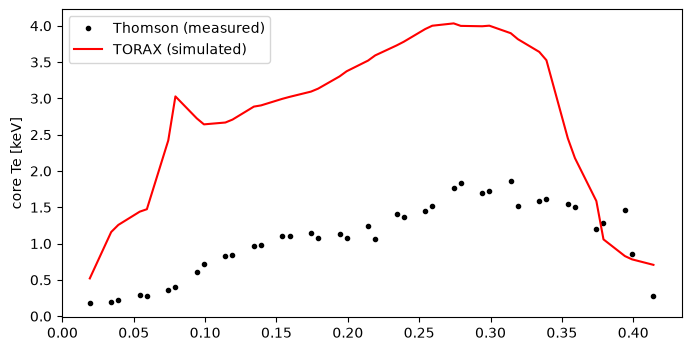

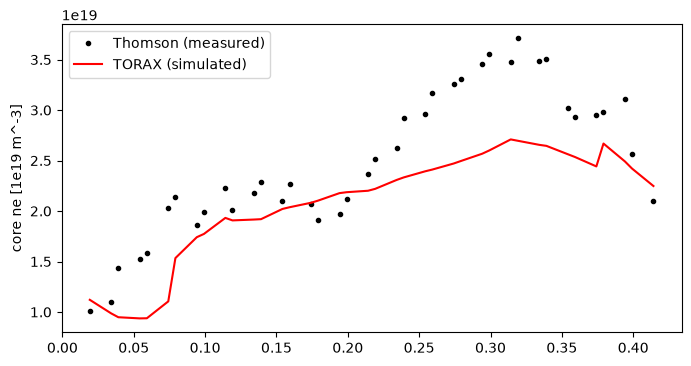

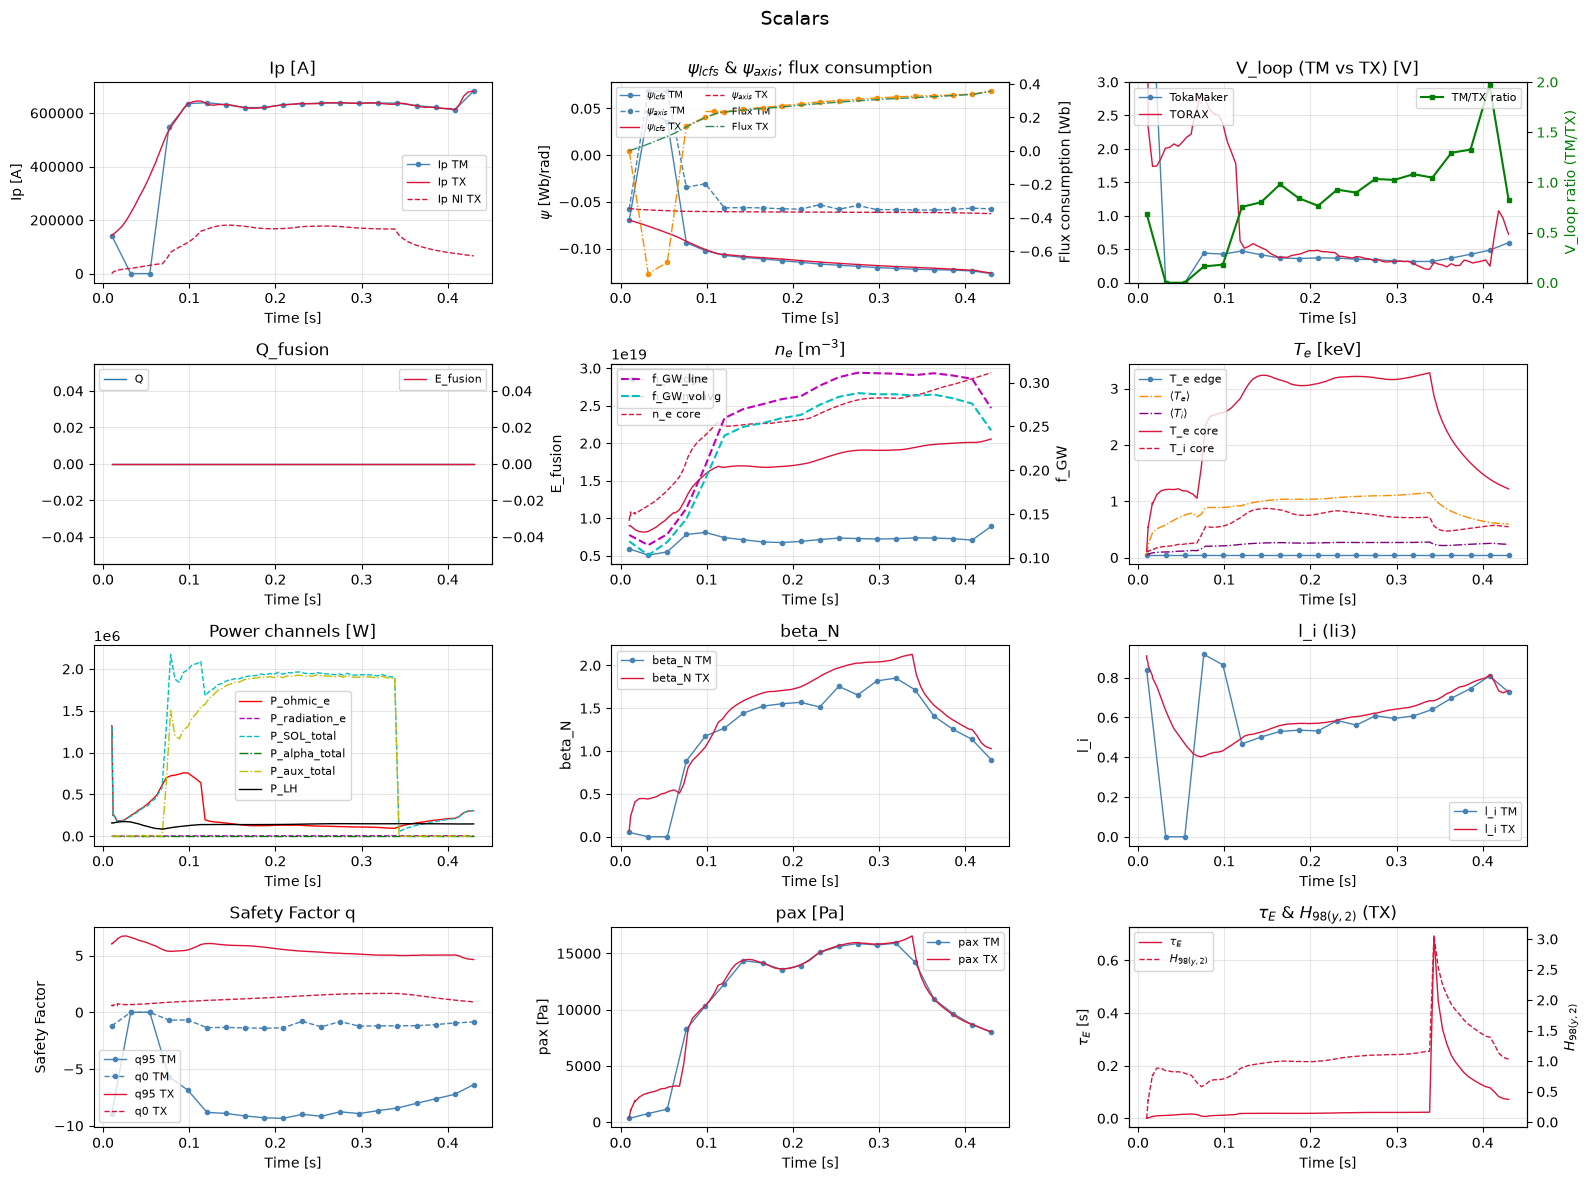

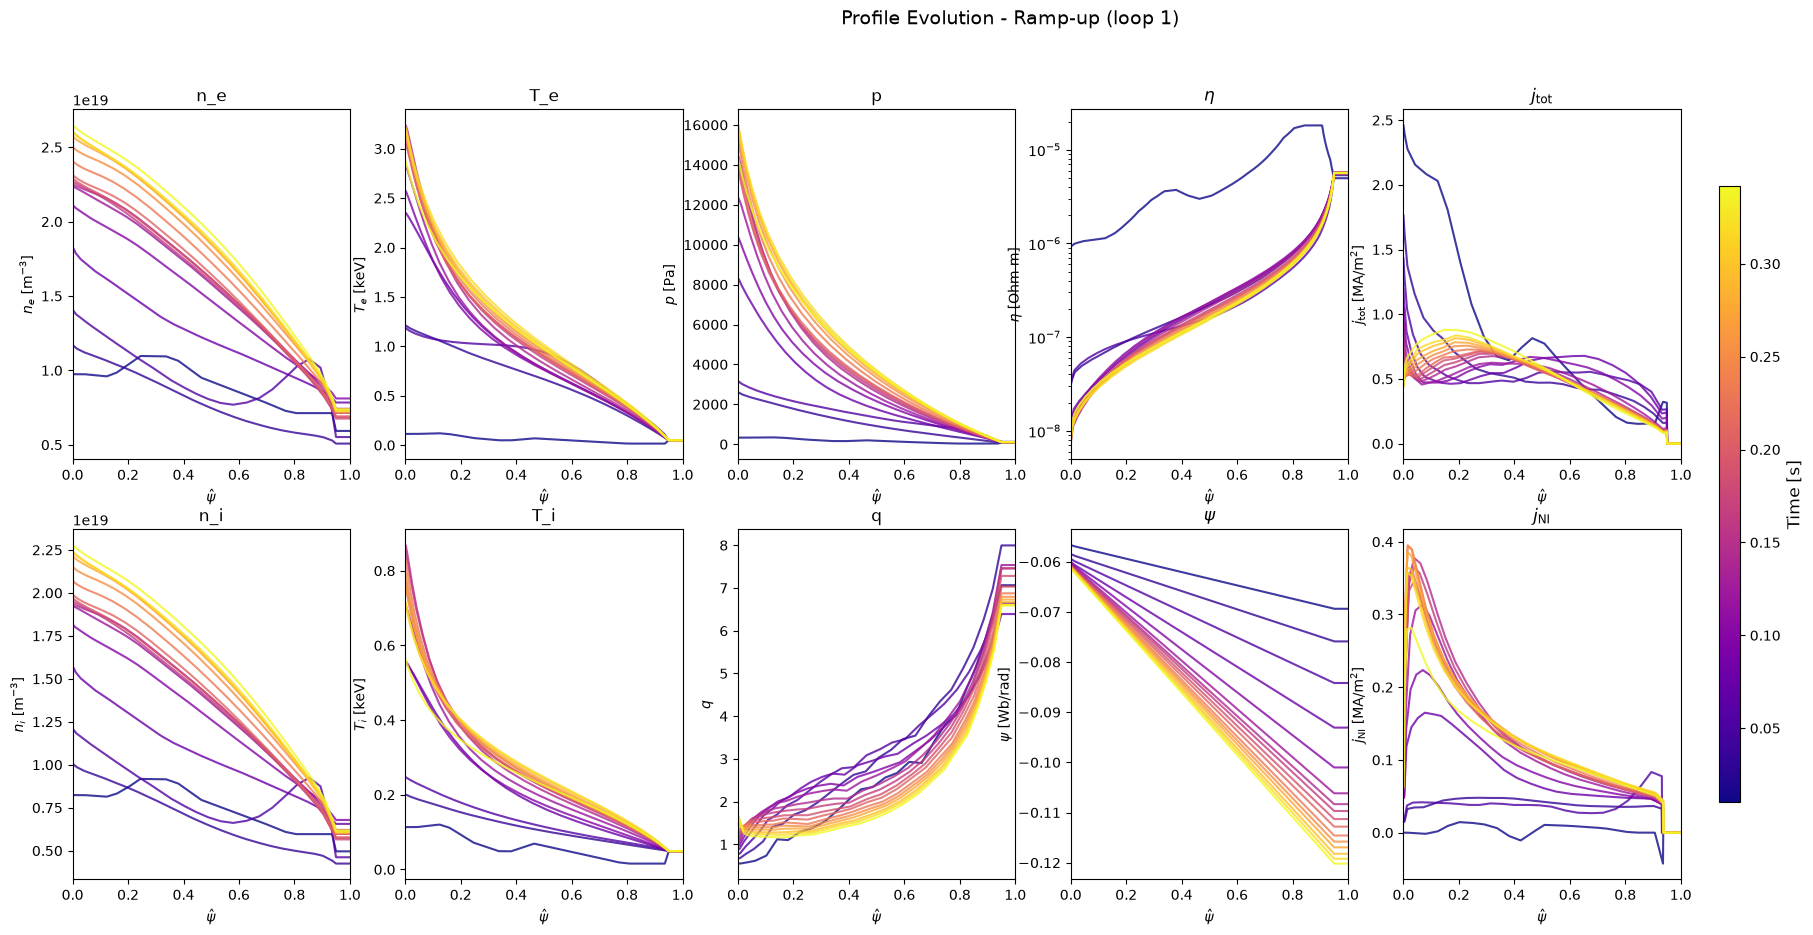

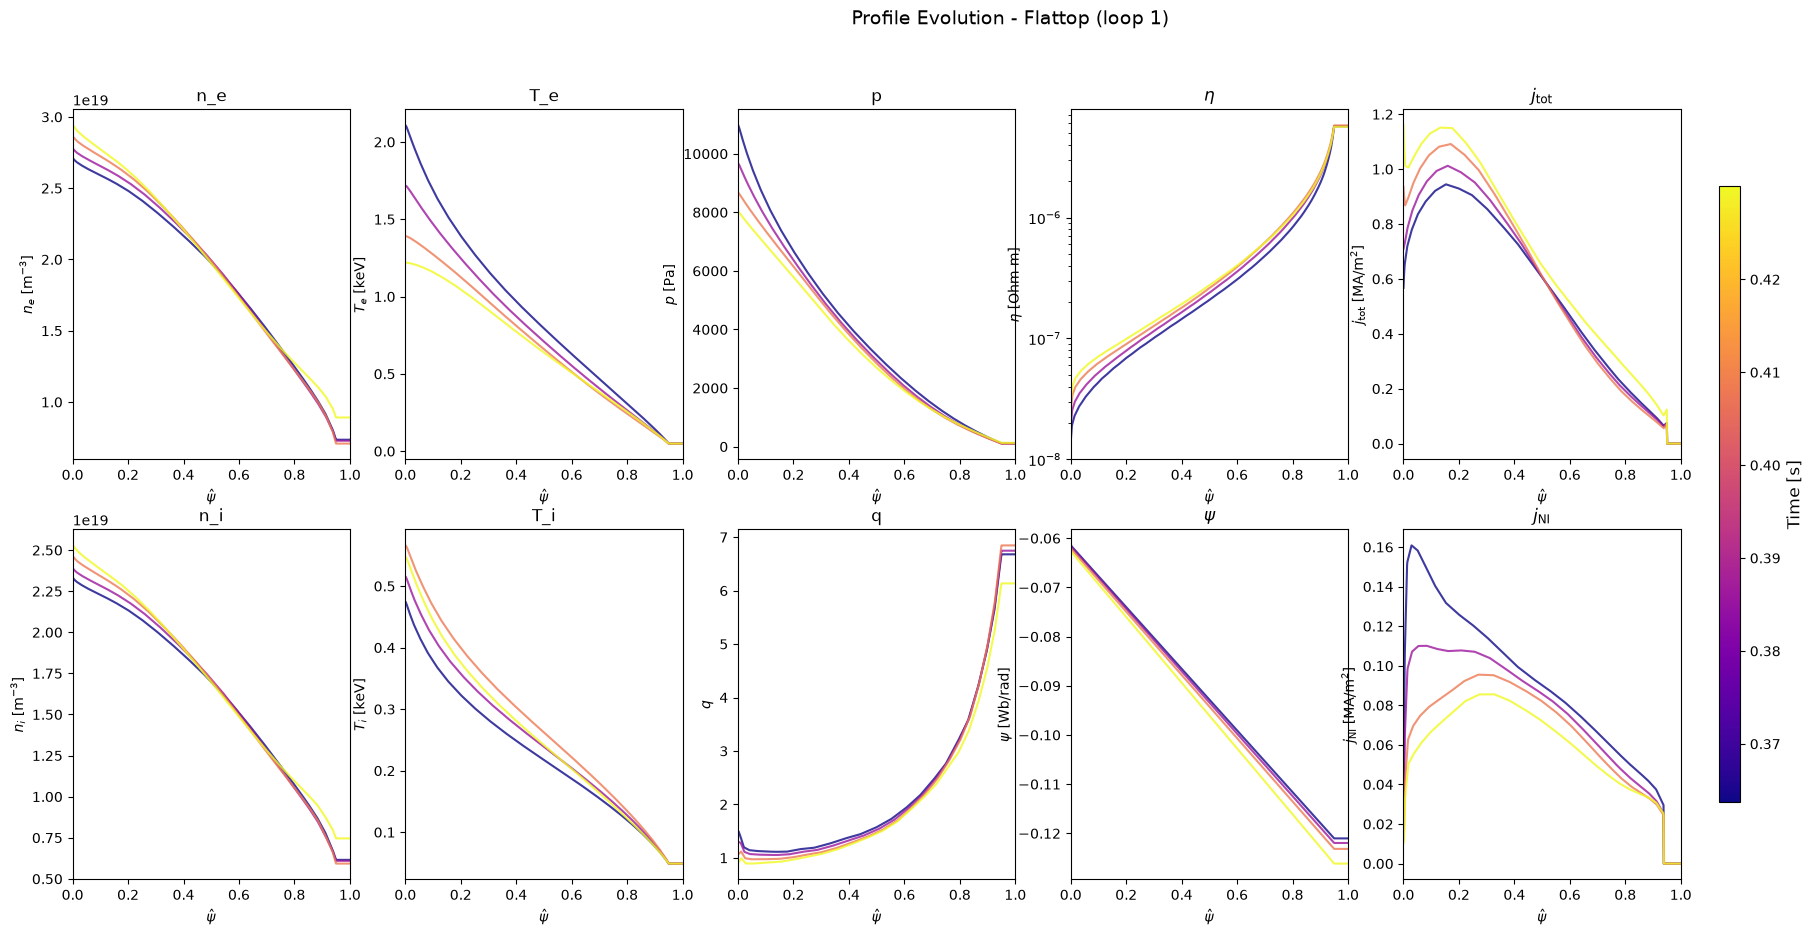

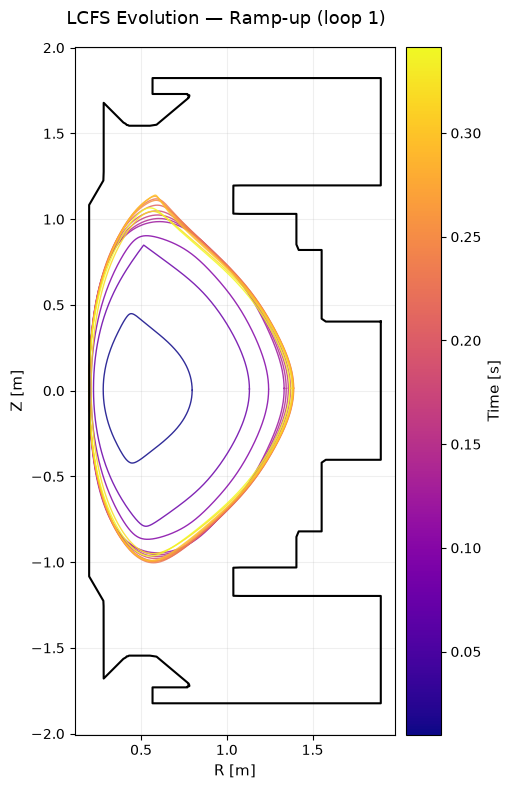

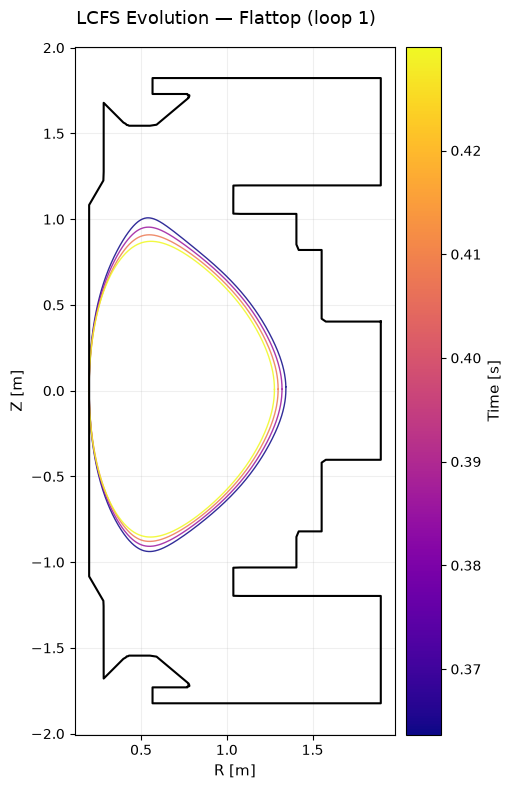

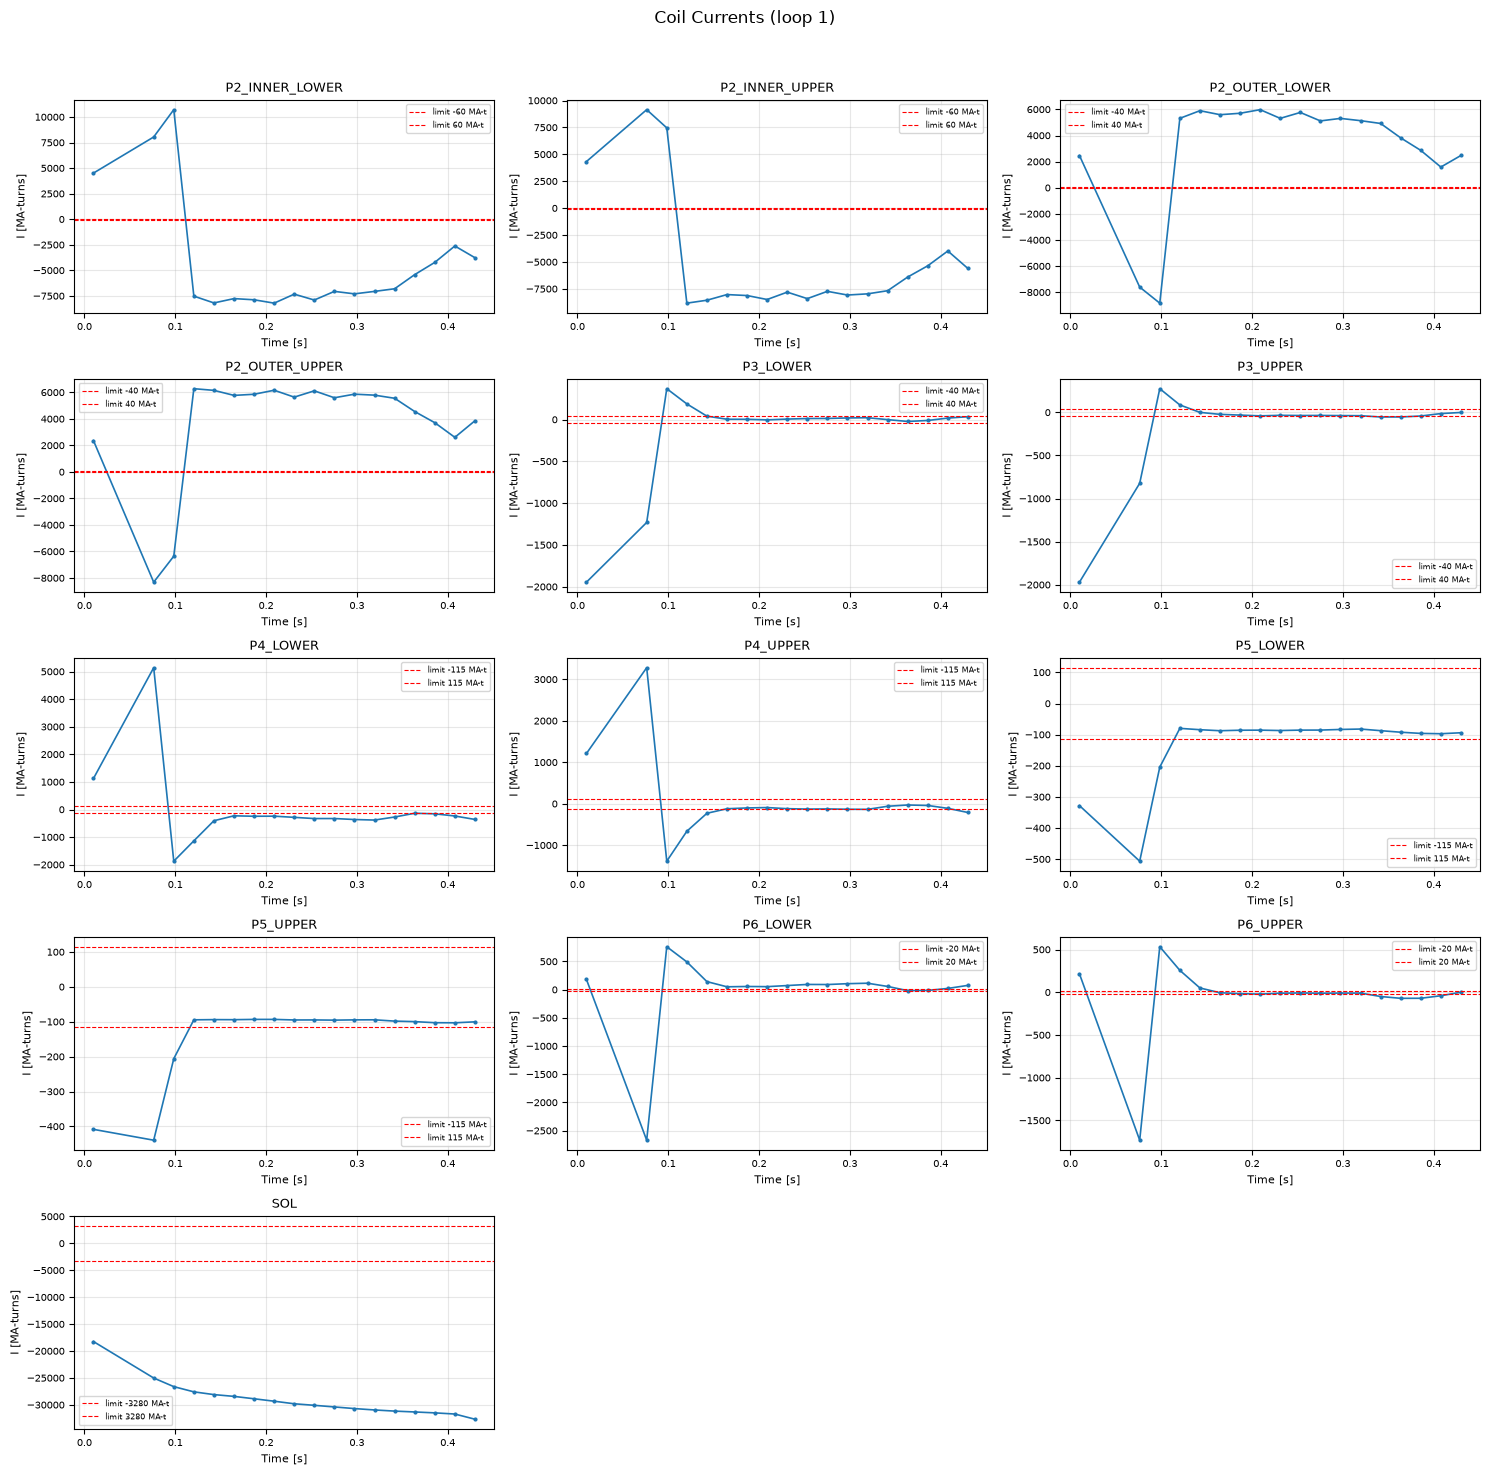

EFIT (efm)              85 timestamps, median step 5.00 ms
core Thomson (ayc)      42 timestamps, median step 5.00 ms
TORAX output            90 timestamps
TokaMaker solves        20 timestamps
time [s]   rho    measured Te [keV]   simulated Te [keV]
  0.023   0.04         0.174            1.130
  0.063   0.03         0.289            1.127
  0.103   0.01         0.663            2.602
  0.143   0.03         1.059            3.222
  0.183   0.03         1.162            3.049
  0.223   0.05         1.339            3.125
  0.263   0.05         1.166            3.185
  0.303   0.04         1.086            3.148
  0.343   0.04         0.889            2.869
  0.383   0.03         0.693            1.718
  0.423   0.04         0.569            1.264


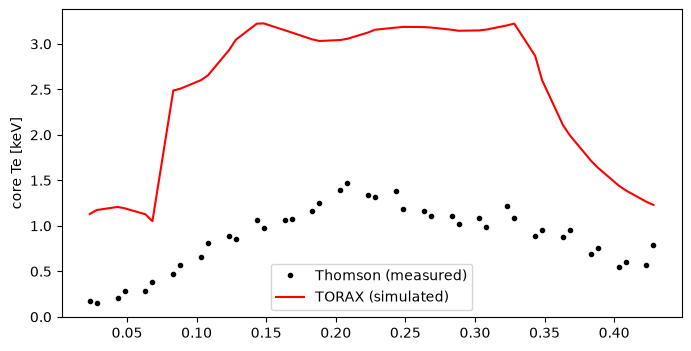

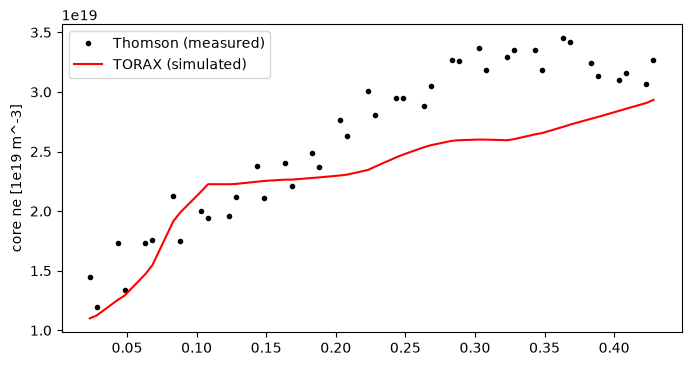

In [ ]:
results = runMastPulses([14625, 14626], maxLoop = 1)
for shotId, result in results.items():
    if result is not None:
        tmtx, diagnostics = result
# [14625, 14626, 30342] - tested
# usableIds = pd.read_csv('MAST_info/usable_pulses.csv')
# batchResults = runMastPulses(usableIds['shot_id'].tolist(), plot=False, verbose=False)